In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

pd.set_option('display.max_colwidth', 80)

In [2]:
# Update this path to your actual log file
LOG_PATH = r"D:\Projects\jupyter\Log Mining\Hadoop_2k.log"

with open(LOG_PATH, "r", encoding="utf-8", errors="replace") as f:
    raw_lines = f.readlines()

print(f"Total lines: {len(raw_lines)}")
print("--- First 5 lines ---")
for line in raw_lines[:5]:
    print(line.strip())

Total lines: 2000
--- First 5 lines ---
2015-10-18 18:01:47,978 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: Created MRAppMaster for application appattempt_1445144423722_0020_000001
2015-10-18 18:01:48,963 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: Executing with tokens:
2015-10-18 18:01:48,963 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: Kind: YARN_AM_RM_TOKEN, Service: , Ident: (appAttemptId { application_id { id: 20 cluster_timestamp: 1445144423722 } attemptId: 1 } keyId: -127633188)
2015-10-18 18:01:49,228 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: Using mapred newApiCommitter.
2015-10-18 18:01:50,353 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: OutputCommitter set in config null


In [3]:
LOG_PATTERN = re.compile(
    r'(?P<timestamp>\d{4}-\d{2}-\d{2}\s\d{2}:\d{2}:\d{2},\d+)'   # 2015-10-18 18:01:47,978
    r'\s+(?P<level>INFO|WARN|ERROR|DEBUG|FATAL)'                   # INFO
    r'\s+\[(?P<thread>[^\]]+)\]'                                   # [main]
    r'\s+(?P<component>[\w\.$]+)'                                   # org.apache...MRAppMaster
    r':\s+(?P<message>.+)'                                          # message text
)

# Test on your actual lines
test = "2015-10-18 18:01:47,978 INFO [main] org.apache.hadoop.mapreduce.v2.app.MRAppMaster: Created MRAppMaster for application appattempt_1445144423722_0020_000001"
m = LOG_PATTERN.match(test)
if m:
    print("Match OK:", m.groupdict())
else:
    print("No match")

Match OK: {'timestamp': '2015-10-18 18:01:47,978', 'level': 'INFO', 'thread': 'main', 'component': 'org.apache.hadoop.mapreduce.v2.app.MRAppMaster', 'message': 'Created MRAppMaster for application appattempt_1445144423722_0020_000001'}


In [5]:
records = []
failed_lines = []

with open(r"D:\Projects\jupyter\Log Mining\Hadoop_2k.log", "r", encoding="utf-8", errors="replace") as f:
    raw_lines = f.readlines()

for line in raw_lines:
    m = LOG_PATTERN.match(line.strip())
    if m:
        records.append(m.groupdict())
    else:
        failed_lines.append(line.strip())

df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S,%f')

# Shorten component to last part only (e.g. MRAppMaster)
df['component_short'] = df['component'].str.split('.').str[-1]

print(f"Parsed : {len(df)}")
print(f"Failed : {len(failed_lines)}")
df.head()

Parsed : 2000
Failed : 0


,timestamp,level,thread,component,message,component_short
0,2015-10-18 18:01:47.978,INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,Created MRAppMaster for application appattempt_1445144423722_0020_000001,MRAppMaster
1,2015-10-18 18:01:48.963,INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,Executing with tokens:,MRAppMaster
2,2015-10-18 18:01:48.963,INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,"Kind: YARN_AM_RM_TOKEN, Service: , Ident: (appAttemptId { application_id { i...",MRAppMaster
3,2015-10-18 18:01:49.228,INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,Using mapred newApiCommitter.,MRAppMaster
4,2015-10-18 18:01:50.353,INFO,main,org.apache.hadoop.mapreduce.v2.app.MRAppMaster,OutputCommitter set in config null,MRAppMaster


In [6]:
# See what didn't parse — often continuation lines or stack traces
print(f"Sample failed lines:")
for line in failed_lines[:5]:
    print(" >", line[:120])

Sample failed lines:


In [7]:
# Remove variables (numbers, IPs, hashes) to get the message "type"
def extract_message_type(msg):
    msg = re.sub(r'\b\d+\b', '#', msg)        # numbers → #
    msg = re.sub(r'\b[a-f0-9]{6,}\b', '#', msg)   # hex IDs → #
    msg = re.sub(r'\d+\.\d+\.\d+\.\d+', '#IP', msg) # IPs → #IP
    return msg.strip()

df['msg_type'] = df['message'].apply(extract_message_type)

# Top 10 most common message types
df['msg_type'].value_counts().head(10)

msg_type
Address change detected. Old: msra-sa-#/#.#.#.#:# New: msra-sa-#:#                                                                                               476
Failed to renew lease for [DFSClient_NONMAPREDUCE_1537864556_1] for # seconds.  Will retry shortly ...                                                           326
ERROR IN CONTACTING RM.                                                                                                                                          147
Retrying connect to server: msra-sa-#:#. Already tried # time(s); retry policy is RetryUpToMaximumCountWithFixedSleep(maxRetries=#, sleepTime=# MILLISECONDS)    146
Recalculating schedule, headroom=<memory:#, vCores:-#>                                                                                                           131
Reduce slow start threshold not met. completedMapsForReduceSlowstart #                                                                                           130
P

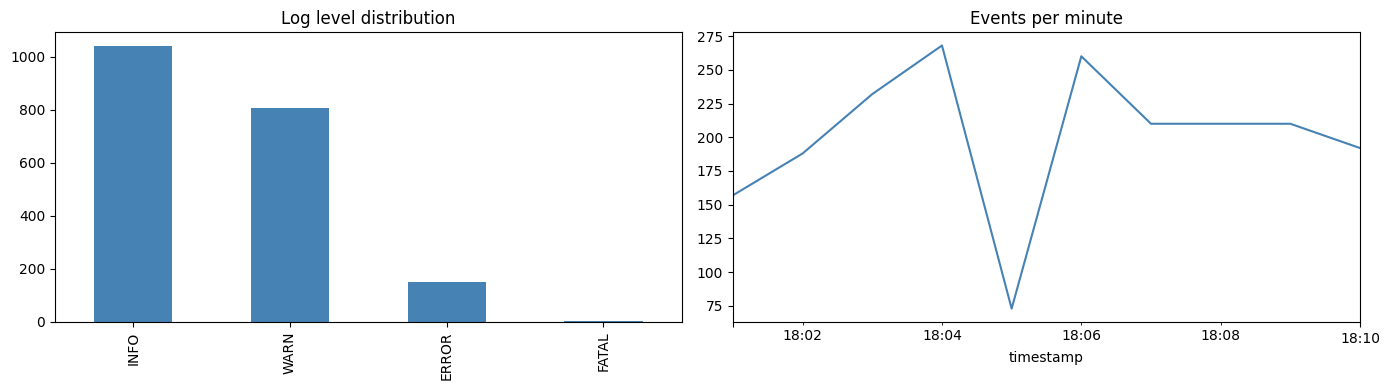

In [8]:
# Plot 1: log level distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['level'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='none'
)
axes[0].set_title('Log level distribution')
axes[0].set_xlabel('')

# Plot 2: events over time
df.set_index('timestamp').resample('1min').size().plot(
    ax=axes[1], color='steelblue'
)
axes[1].set_title('Events per minute')

plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- assumes df is already parsed from previous steps ---

# Step 1: extract app/attempt identifier from message
def extract_identifier(msg):
    m = re.search(r'(appattempt_\d+_\d+_\d+|application_\d+_\d+)', msg)
    return m.group(1) if m else None

df['identifier'] = df['message'].apply(extract_identifier)

# Step 2: strip variables to get message type
def get_msg_type(msg):
    msg = re.sub(r'appattempt_\S+', '<id>', msg)
    msg = re.sub(r'application_\S+', '<id>', msg)
    msg = re.sub(r'container_\S+', '<id>', msg)
    msg = re.sub(r'\d+\.\d+\.\d+\.\d+:\d+', '<host>', msg)
    msg = re.sub(r'\b\d+\b', '#', msg)
    return msg.strip()[:80]   # truncate for cleaner column names

df['msg_type'] = df['message'].apply(get_msg_type)

# Step 3: keep only rows that have an identifier
df_id = df[df['identifier'].notna()].copy()
print(f"Rows with identifiers: {len(df_id)} / {len(df)}")
print(f"Unique identifiers: {df_id['identifier'].nunique()}")
print(f"Unique message types: {df_id['msg_type'].nunique()}")

Rows with identifiers: 13 / 2000
Unique identifiers: 2
Unique message types: 2
